$$
source ----------p--------\gt LENS1 -----------d---------\gt LENS2
$$

$$
p+\left( 1-\frac{p}{f_1} \right) d \geq 500
$$

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
p = np.arange(0, 80, 0.5)
d = np.arange(0, 150, 0.5)

#solve for equal to 500
f_values=[]

for i in p:
    f=[]
    for j in d:
        if i+j>200: 
            f.append(0) 
        else:
            f_value = (i*j) / (i+j - 500)
            f.append(f_value)
    f_values.append(f)

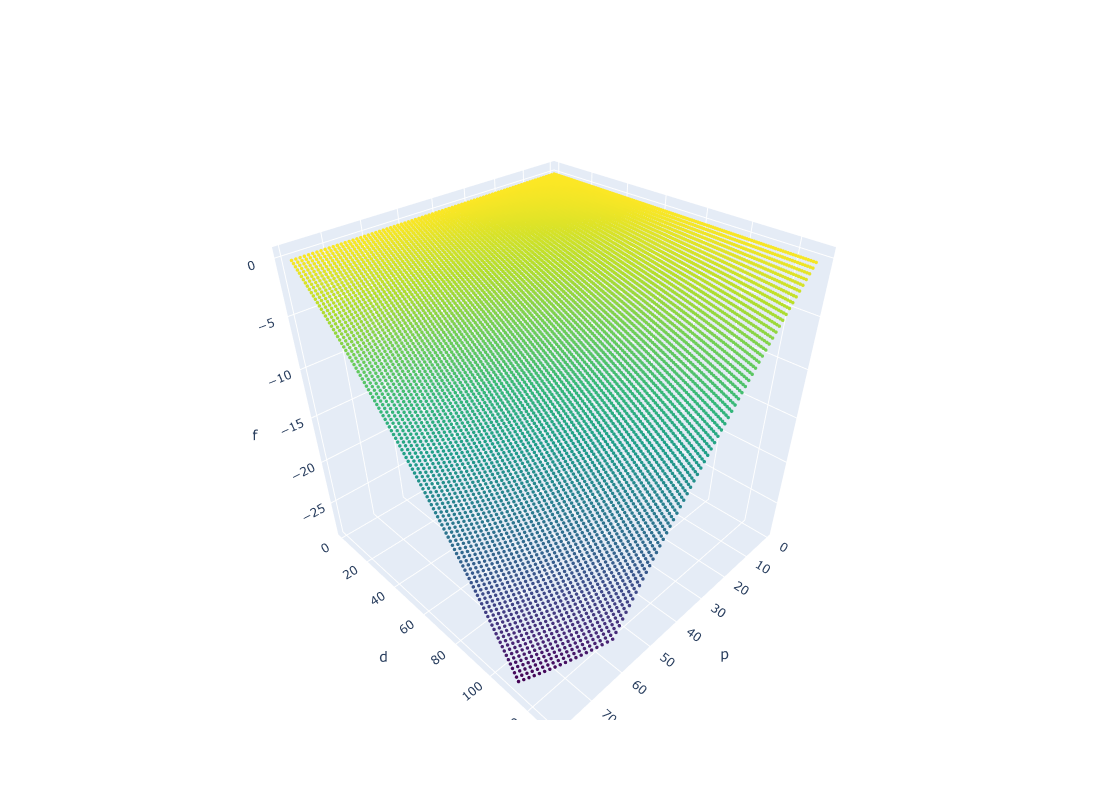

In [11]:
import numpy as np
import plotly.graph_objects as go

p = np.arange(0, 80, 1)
d = np.arange(0, 130, 1)

P, D = np.meshgrid(p, d)

# Initialize
F = np.zeros_like(P, dtype=float)

# Compute only valid region AND avoid zero denominator
valid = (P + D <= 190) & (P + D != 500)

F[valid] = (P[valid] * D[valid]) / (P[valid] + D[valid] - 500)

# Final mask: remove zeros, inf, nan
mask = (F != 0) & np.isfinite(F)

fig = go.Figure(
    data=go.Scatter3d(
        x=P[mask],
        y=D[mask],
        z=F[mask],
        mode='markers',
        marker=dict(
            size=2,
            color=F[mask],
            colorscale='Viridis'
        )
    )
)

fig.update_layout(
    width=1000,
    height=800,
    scene=dict(
        aspectmode='cube',
        xaxis_title='p',
        yaxis_title='d',
        zaxis_title='f'
    )
)

fig.show()


In [12]:
## given NA=0.07, a function that calculates the focal length of f2 given the p, d and q distances and f1

In [13]:
def calculate_f2(p, d, q, f1):
    #first surface
    u0 = 0.07
    y1 = u0*p
    u1 = u0 - (y1/f1)
    #print(u1)
    #second surface
    y2 = y1 + u1*d
    #print(y2)
    #f2 calculation
    f2 = 1 / ((u1/y2) + (1/q))

    return f2

In [14]:
37.1 + (0.595 - (37.1/calculate_f2(105, 50, 200000, -14))*200000)

-118999.405

In [15]:
#get all non-valid points (p,d, f1)
points = np.column_stack((P[mask], D[mask], F[mask]))
points_index = np.arange(0, len(points), 1)

In [16]:
f2_array = []
q = np.array([100000, 150000, 200000])
for point in points:
    f2_array.append(calculate_f2(point[0], point[1], q[-1], point[2]))

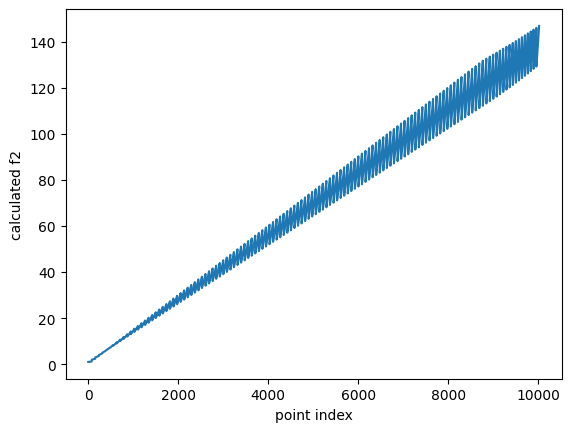

In [17]:
plt.plot(points_index, f2_array)
plt.xlabel("point index")
plt.ylabel("calculated f2")
#plt.ylim(50,100)
#plt.xlim(200,600)
plt.show()

## calculate the q deviation to move the range across the limits

In [18]:
mask = (F != 0) & np.isfinite(F)
points = np.column_stack((P[mask], D[mask], F[mask], f2_array)) #valid points(p, d, f1, f2) for q defined above(default 200m)

In [19]:
#I dont know how to do that so lets just move the p 1mm to see the change in q.
def calculate_q(point, p_deviation):
    p, d, f1, f2 = point
    
    u0 = 0.07
    y0 = 0

    #first surface
    y1 = y0 + u0*(p+p_deviation)
    u1 = u0 - (y1/f1)

    #second surface
    y2 = y1 + u1*d
    u2 = u1 - (y2/f2)

    q_new = -y2/u2
    return q_new

In [20]:
q_news = []
p_dev = 1 #try moving 1 mm 
for point in points:
    q_news.append(calculate_q(point, p_dev))
q_news = np.array(q_news)
q_dev = q[-1] - q_news

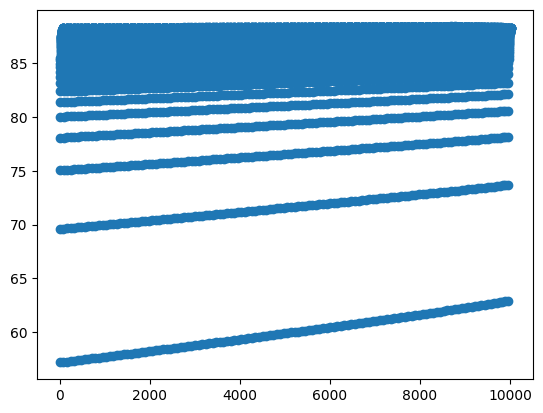

In [21]:
plt.scatter(points_index, q_dev/1000)
#plt.xlim(60000, 80000)
#plt.ylim(0, 100000)
#plt.ylim(-0.5,0.5)
plt.show()

In [22]:
#lets take a point in the middle
points[104]
R1_values[104]

NameError: name 'R1_values' is not defined

In [23]:
select = points[104]
#effl
f_inv = (1/select[3]) + (1/select[2] - (select[1]/(select[2]*select[3])))
print("effl = " + str(1/f_inv))

effl = 477.1517709673071


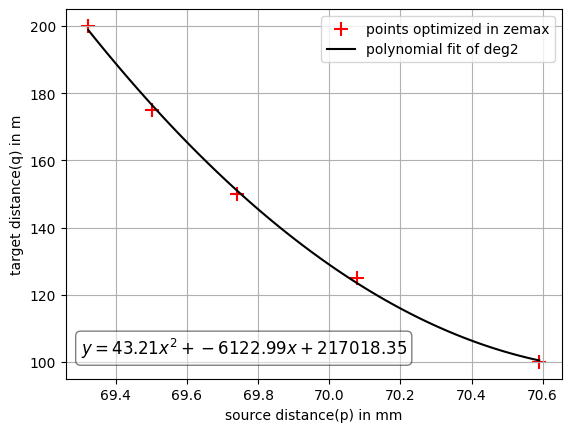

In [24]:
import numpy as np
import matplotlib.pyplot as pl

p_distances = [7.059029265837000E+001, 7.007909449589000E+001, 6.974173218049000E+001, 
               6.950183297188001E+001, 6.932314150908999E+001]
target_distances = [100, 125, 150, 175, 200]

# Fit 2nd degree polynomial
coeffs = np.polyfit(p_distances, target_distances, 2)
p = np.poly1d(coeffs)

# Plotting
xp = np.linspace(min(p_distances), max(p_distances), 100)
plt.scatter(p_distances, target_distances, s=100, marker='+', c="red", label="points optimized in zemax")
plt.plot(xp, p(xp), '-', c="black", label="polynomial fit of deg2")
plt.xlabel("source distance(p) in mm")
plt.ylabel("target distance(q) in m")
# Formatting the equation string
equation_label = f"$y = {coeffs[0]:.2f}x^2 + {coeffs[1]:.2f}x + {coeffs[2]:.2f}$"

# Placing the text (transform=plt.gca().transAxes uses relative coordinates 0-1)
plt.text(0.03, 0.05, equation_label, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.legend()
plt.grid()
plt.savefig('BonusTargeting.png', dpi=300)
plt.show()


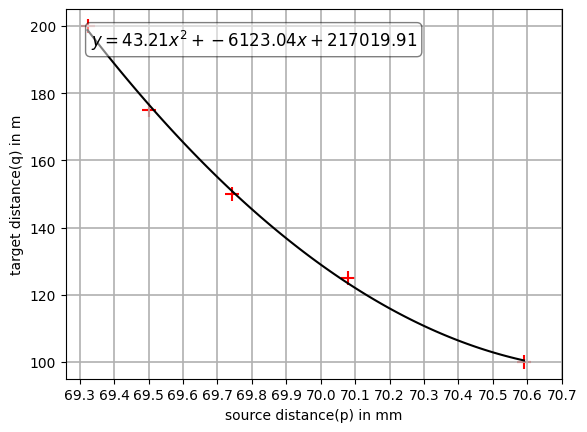

In [39]:
import numpy as np
import matplotlib.pyplot as plt

p_distances = [70.59029, 70.07909, 69.74173, 69.50183, 69.32314]
target_distances = [100, 125, 150, 175, 200]

coeffs = np.polyfit(p_distances, target_distances, 2)
p = np.poly1d(coeffs)
xp = np.linspace(min(p_distances), max(p_distances), 100)

plt.scatter(p_distances, target_distances, s=100, marker='+', c="red")
plt.plot(xp, p(xp), '-', c="black")


plt.xlabel("source distance(p) in mm")
plt.ylabel("target distance(q) in m")
plt.xticks(np.arange(69.3, 70.7, 0.1))
plt.grid(linewidth=1.2)
plt.show()

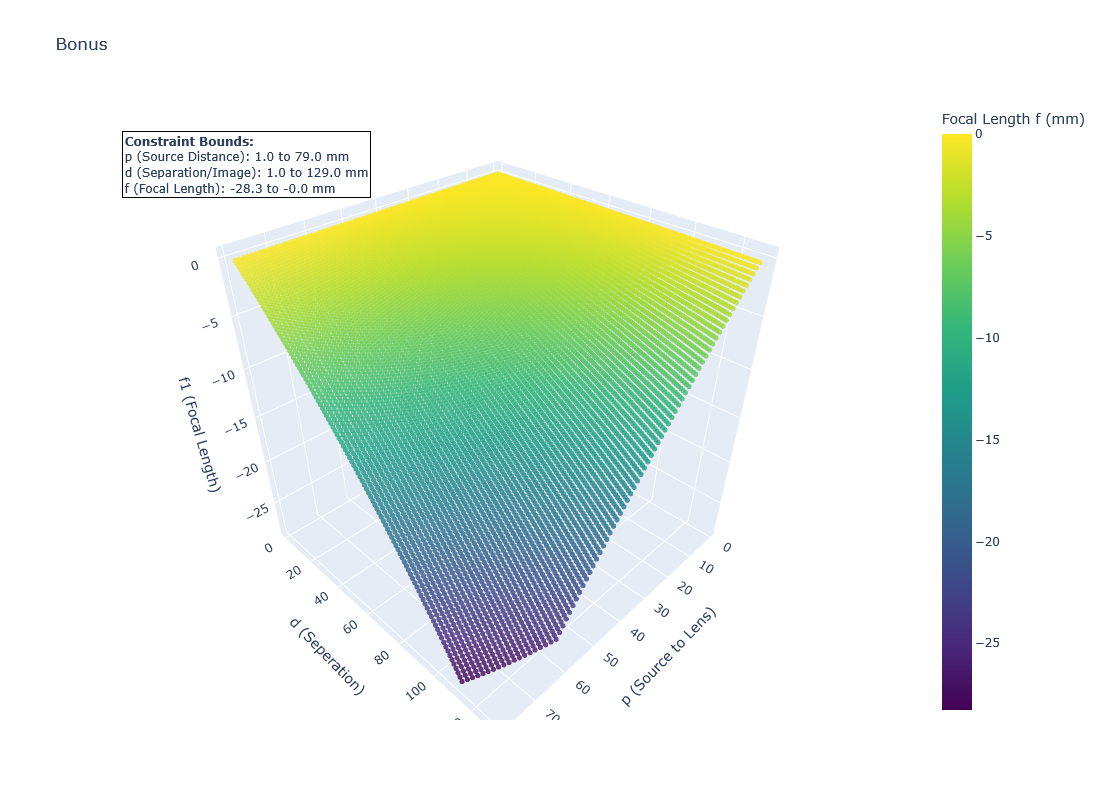

In [7]:
import numpy as np
import plotly.graph_objects as go

# --- 1. Define Search Space ---
p = np.arange(0, 80, 1)
d = np.arange(0, 130, 1)
P, D = np.meshgrid(p, d)

# --- 2. Paraxial Solve ---
# Initialize
F_val = np.zeros_like(P, dtype=float)

# Compute only valid region AND avoid zero denominator
# Note: The '500' constant in your formula represents a specific 
# system constraint or a combined track length target.
valid = (P + D <= 190) & (P + D != 500)

with np.errstate(divide='ignore', invalid='ignore'):
    F_val[valid] = (P[valid] * D[valid]) / (P[valid] + D[valid] - 500)

# Final mask: remove zeros, inf, nan
mask = (F_val != 0) & np.isfinite(F_val)

# --- 3. Range Calculations ---
p_min, p_max = np.min(P[mask]), np.max(P[mask])
d_min, d_max = np.min(D[mask]), np.max(D[mask])
f_min, f_max = np.min(F_val[mask]), np.max(F_val[mask])

stats_text = (
    f"<b>Constraint Bounds:</b><br>"
    f"p (Source Distance): {p_min:.1f} to {p_max:.1f} mm<br>"
    f"d (Separation/Image): {d_min:.1f} to {d_max:.1f} mm<br>"
    f"f (Focal Length): {f_min:.1f} to {f_max:.1f} mm"
)

# --- 4. Plotting ---
fig = go.Figure(
    data=go.Scatter3d(
        x=P[mask],
        y=D[mask],
        z=F_val[mask],
        mode='markers',
        marker=dict(
            size=3,
            color=F_val[mask],
            colorscale='Viridis',
            colorbar=dict(title="Focal Length f (mm)"),
            showscale=True,
            opacity=0.8
        ),
        hovertemplate="<b>p:</b> %{x}<br><b>d:</b> %{y}<br><b>f:</b> %{z:.2f}<extra></extra>"
    )
)

# Add Annotation Box
fig.add_annotation(
    dict(
        xref="paper", yref="paper",
        x=0.05, y=0.95,
        showarrow=False,
        text=stats_text,
        bgcolor="rgba(255, 255, 255, 0.9)",
        bordercolor="black",
        borderwidth=1,
        font=dict(size=12),
        align="left"
    )
)

fig.update_layout(
    width=800,
    height=800,
    title="Bonus",
    scene=dict(
        aspectmode='cube',
        xaxis_title='p (Source to Lens)',
        yaxis_title='d (Seperation)',
        zaxis_title='f1 (Focal Length)',
    )
)

fig.show()